In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

from collections import Counter
from sklearn.covariance import EllipticEnvelope

In [2]:
df = pd.read_csv('creditcard.csv').drop(['Time'], axis=1)

In [3]:
df.drop_duplicates().Class.value_counts()

Class
0    275190
1       473
Name: count, dtype: int64

In [4]:
df.head(10)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,-0.371407,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,-0.099254,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,1.249376,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,-0.410430,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,-0.366846,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 30 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   V1      284807 non-null  float64
 1   V2      284807 non-null  float64
 2   V3      284807 non-null  float64
 3   V4      284807 non-null  float64
 4   V5      284807 non-null  float64
 5   V6      284807 non-null  float64
 6   V7      284807 non-null  float64
 7   V8      284807 non-null  float64
 8   V9      284807 non-null  float64
 9   V10     284807 non-null  float64
 10  V11     284807 non-null  float64
 11  V12     284807 non-null  float64
 12  V13     284807 non-null  float64
 13  V14     284807 non-null  float64
 14  V15     284807 non-null  float64
 15  V16     284807 non-null  float64
 16  V17     284807 non-null  float64
 17  V18     284807 non-null  float64
 18  V19     284807 non-null  float64
 19  V20     284807 non-null  float64
 20  V21     284807 non-null  float64
 21  V22     28

   feature  importance
0      V10    0.154809
1      V14    0.139288
2       V4    0.128538
3      V12    0.102290
4      V11    0.086573
5      V17    0.073107
6       V3    0.053273
7       V7    0.046660
8      V16    0.038420
9       V2    0.019026
10     V21    0.018972
11      V9    0.011651
12     V19    0.010332
13  Amount    0.009658
14     V18    0.009561
15     V28    0.009482
16     V20    0.009241
17      V6    0.008451
18     V26    0.007858
19     V13    0.007664
20     V27    0.007551
21      V5    0.007115
22     V15    0.006927
23      V8    0.006737
24     V25    0.005903
25     V22    0.005713
26      V1    0.005487
27     V24    0.005262
28     V23    0.004450


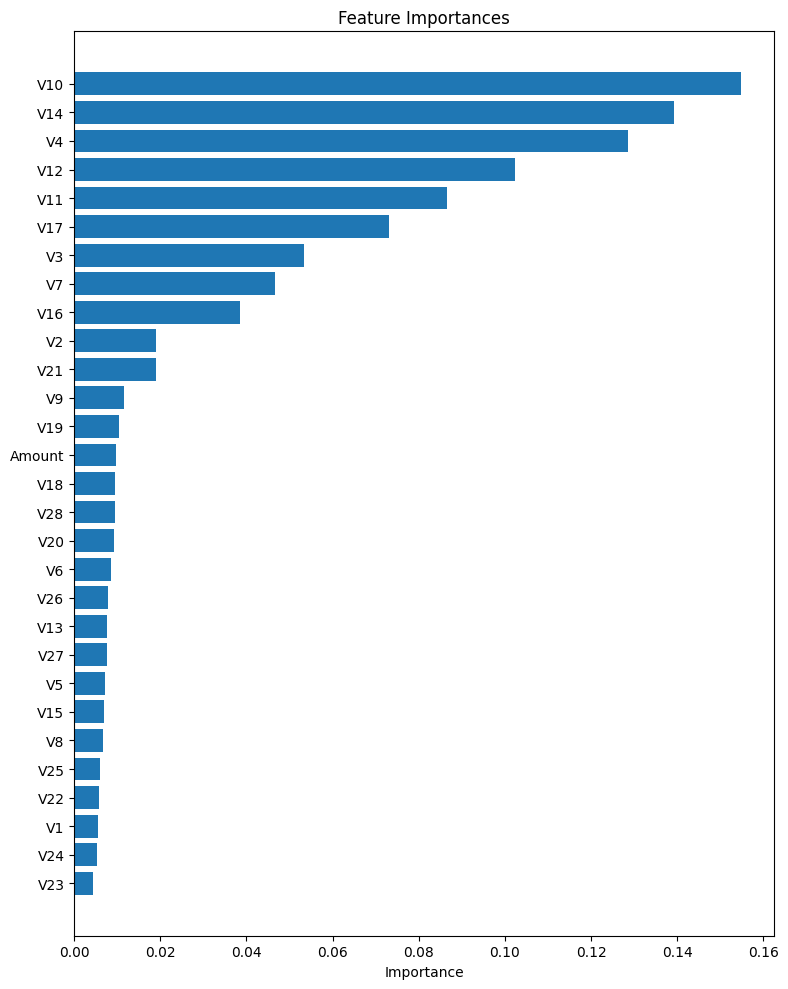

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

clf = RandomForestClassifier(
    n_estimators=100,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced'
)
clf.fit(X_train, y_train)

importances = clf.feature_importances_
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
})
feat_imp = feat_imp.sort_values('importance', ascending=False).reset_index(drop=True)

print(feat_imp)

plt.figure(figsize=(8, 10))
plt.barh(feat_imp['feature'], feat_imp['importance'])
plt.gca().invert_yaxis()
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [7]:
features = ['V10','V14','V4','V12', 'V11', 'V17', 'Class']

In [8]:
df = df[features].copy(deep=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   V10     284807 non-null  float64
 1   V14     284807 non-null  float64
 2   V4      284807 non-null  float64
 3   V12     284807 non-null  float64
 4   V11     284807 non-null  float64
 5   V17     284807 non-null  float64
 6   Class   284807 non-null  int64  
dtypes: float64(6), int64(1)
memory usage: 15.2 MB


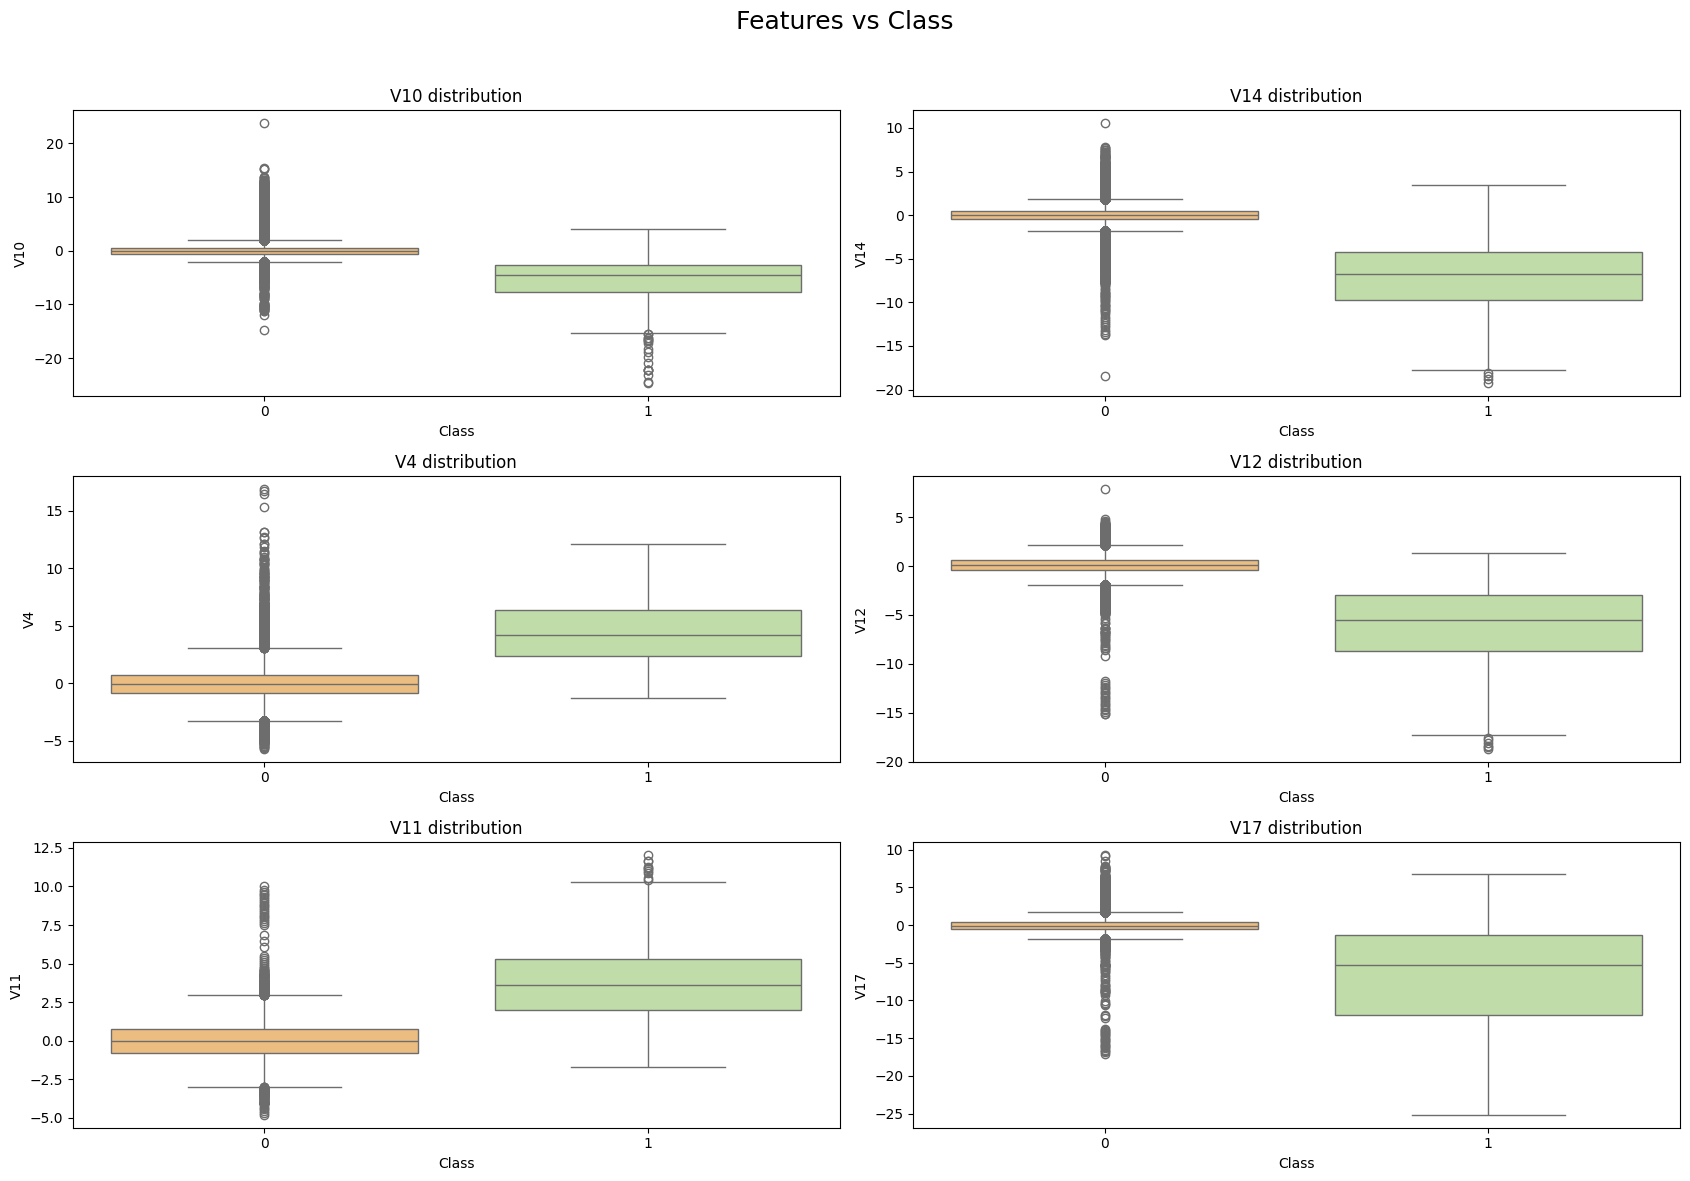

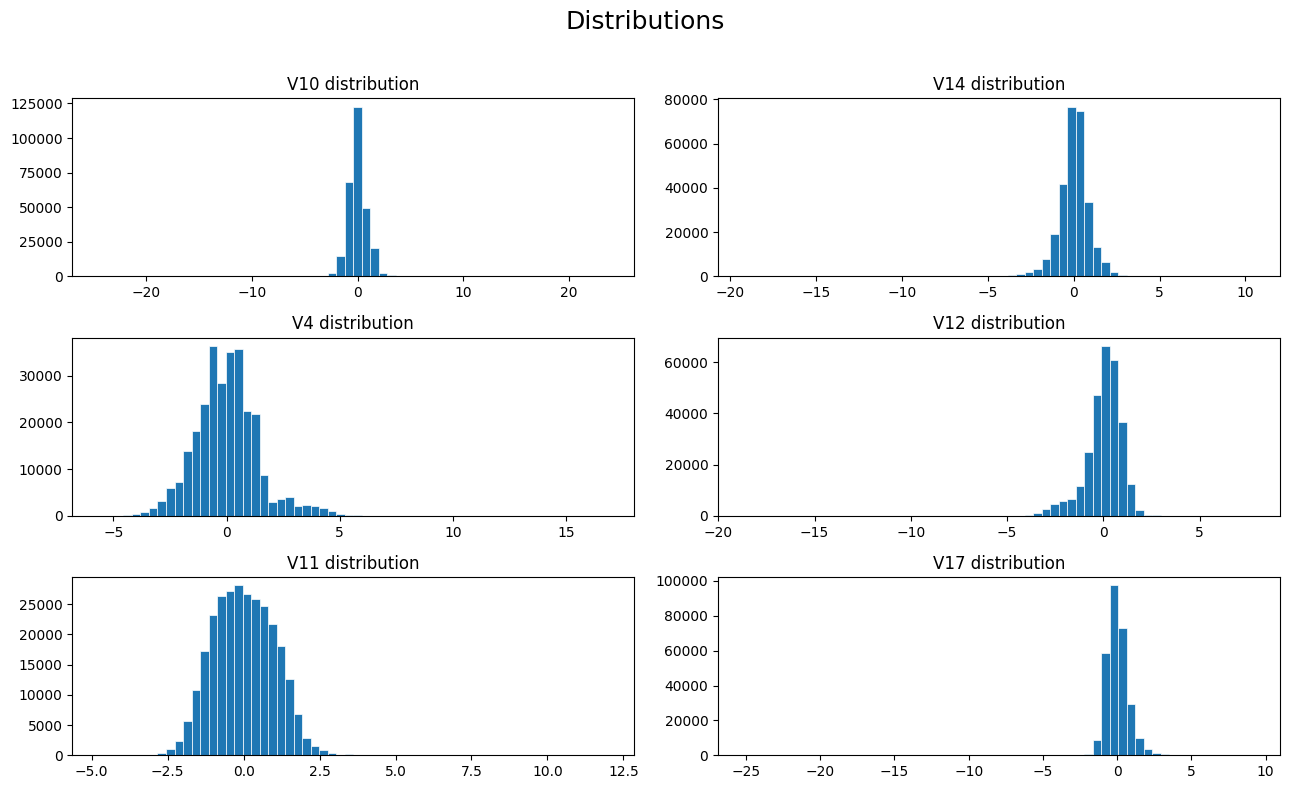

In [10]:
fig, axes = plt.subplots(3,2, figsize=(17, 12))
fig.suptitle('Features vs Class', size=18)

for ax, feat in zip(axes.flatten(), features):
    sns.boxplot(
        ax=ax,
        data=df,
        x='Class',
        y=feat,
        hue='Class',
        palette='Spectral',
        dodge=False
    )
    ax.set_title(f"{feat} distribution")
    ax.get_legend().remove()

plt.tight_layout(rect=[0, 0, 1, 0.96])

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(13, 8))
fig.suptitle('Distributions\n', size=18)

for ax, feat in zip(axes.flatten(), features):
    ax.hist(df[feat], bins=60, linewidth=0.5, edgecolor='white')
    ax.set_title(f"{feat} distribution")

plt.tight_layout()

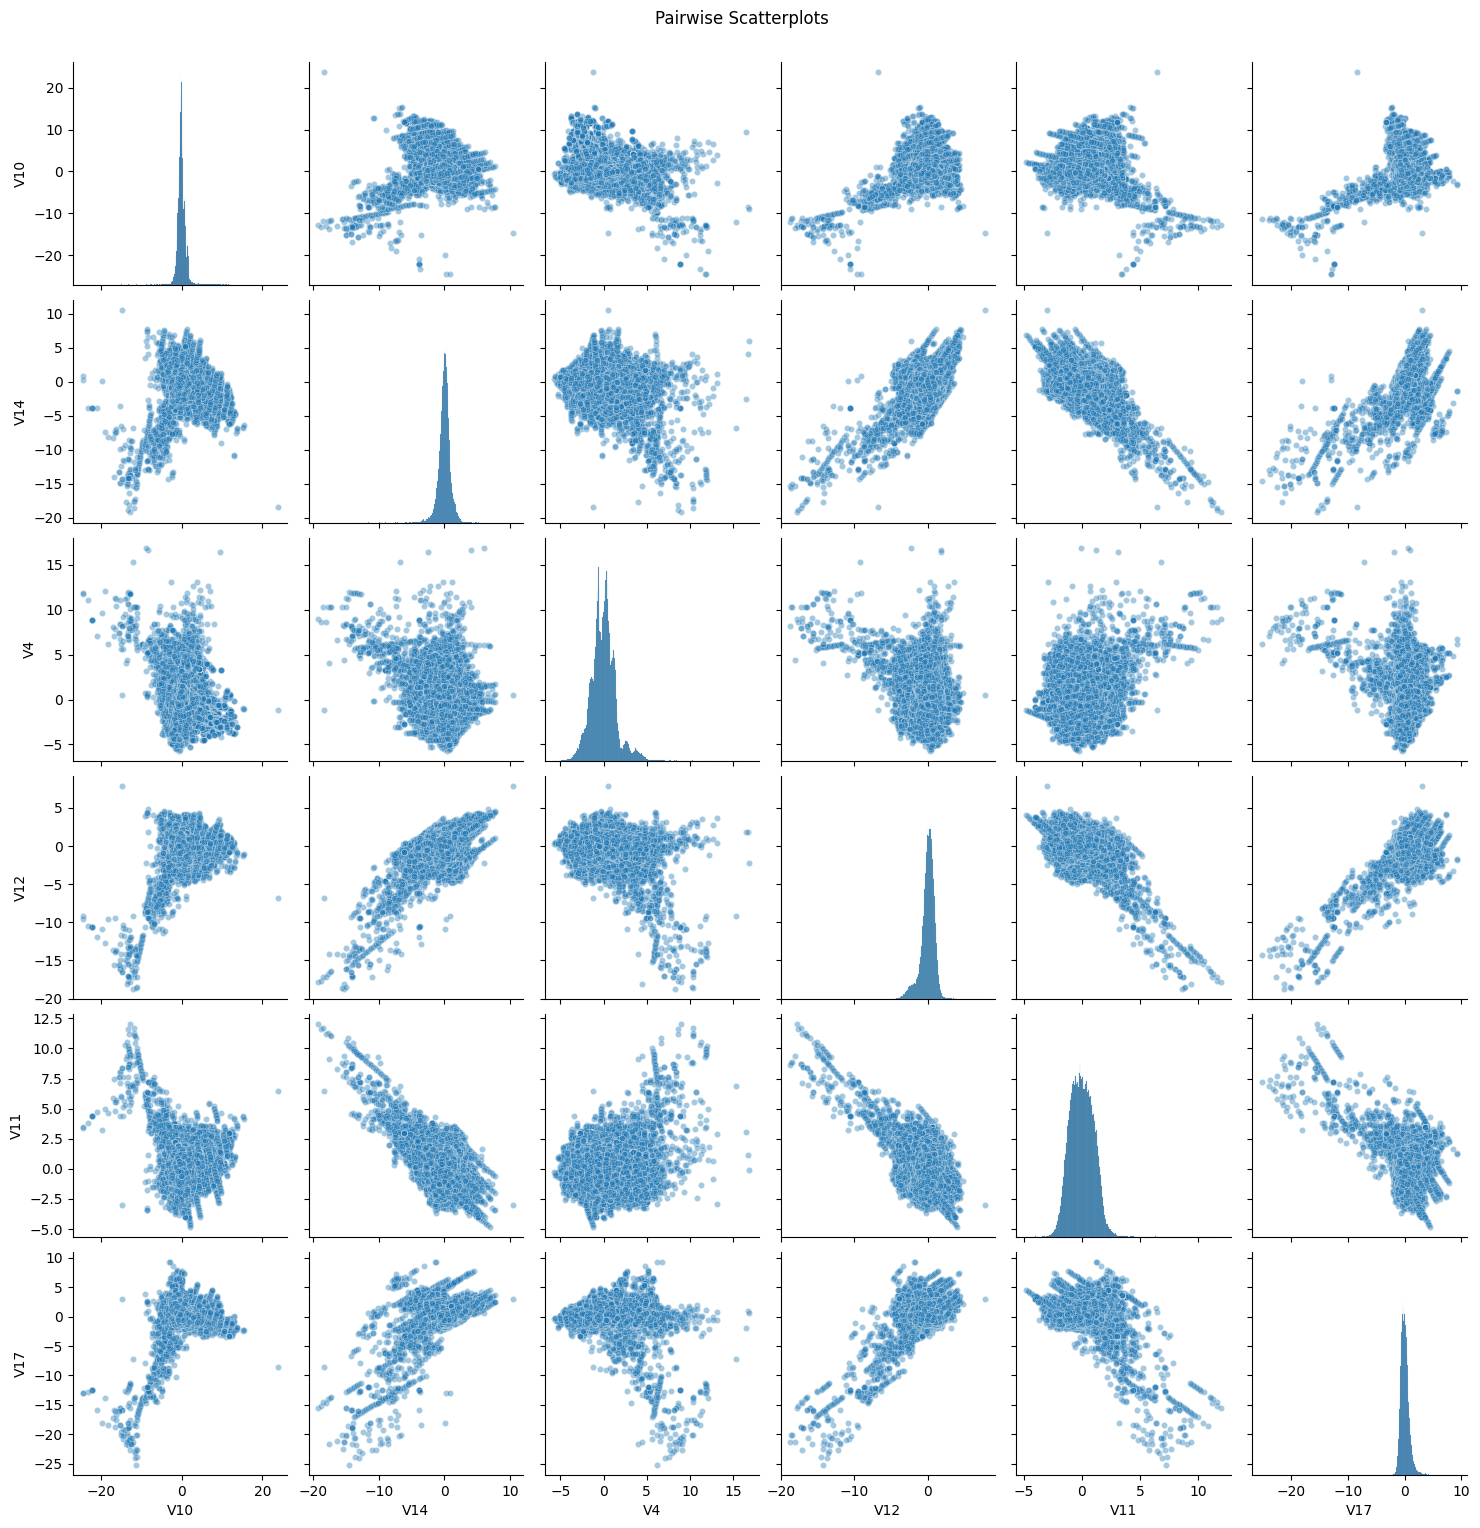

In [11]:
features = ['V10','V14','V4','V12', 'V11','V17']

sns.pairplot(df[features], diag_kind='hist', plot_kws={'alpha':0.4, 's':20})
plt.suptitle('Pairwise Scatterplots', y=1.02)
plt.show()

In [12]:
from sklearn.covariance import EllipticEnvelope

In [13]:
algorithm = EllipticEnvelope(random_state=2021).fit(df)
y_pred = algorithm.predict(df)
y_pred

array([1, 1, 1, ..., 1, 1, 1], shape=(284807,))

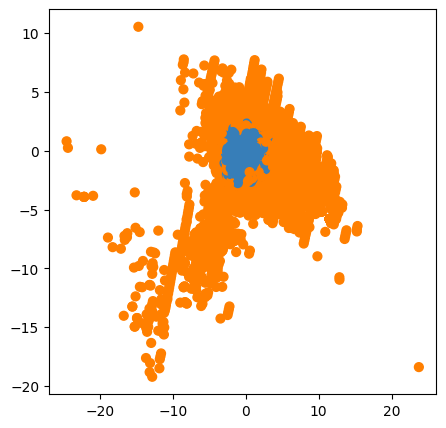

In [14]:
plt.figure(figsize=(5, 5))
colors = np.array(['#377eb8', '#ff7f00'])
plt.scatter(df.iloc[:, 0], df.iloc[:, 1], s=40, color=colors[(y_pred - 1) // 2])

D:\Python\Python313\Lib\site-packages\sklearn\covariance\_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-205.902917813001551 > -299.447213511486495). You may want to try with a higher value of support_fraction (current value: 0.501).
  warnings.warn(
D:\Python\Python313\Lib\site-packages\sklearn\covariance\_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-251.582170242525279 > -268.523931518193137). You may want to try with a higher value of support_fraction (current value: 0.501).
  warnings.warn(
D:\Python\Python313\Lib\site-packages\sklearn\covariance\_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-247.284642613643427 > -266.482846902204699). You may want to try with a higher value of support_fraction (current value: 0.501).
  warnings.warn(
D:\Python\Python

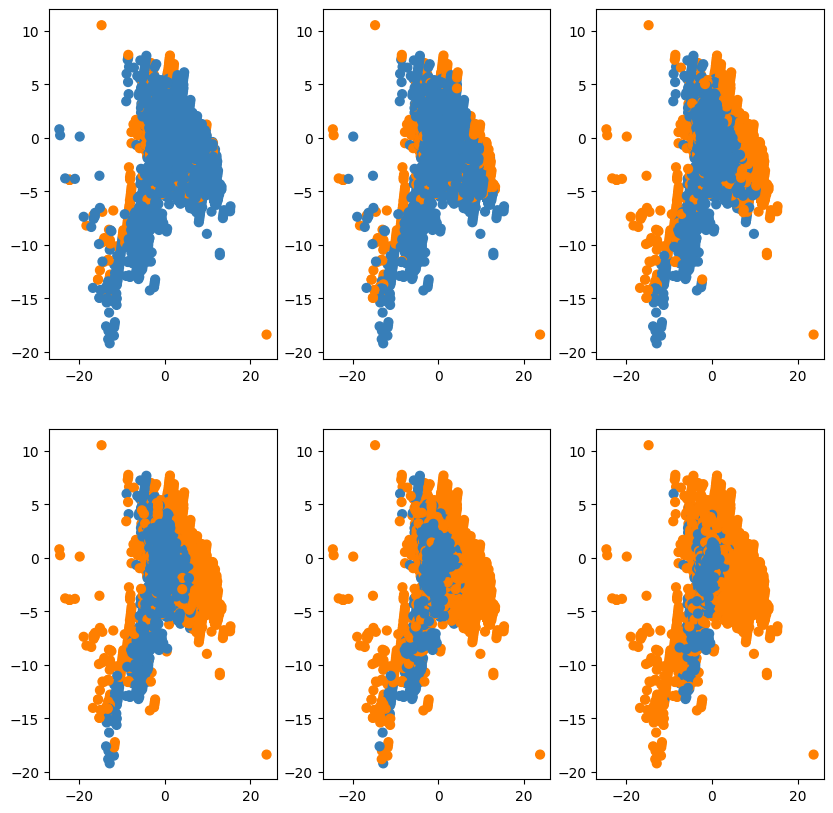

In [15]:
plt.figure(figsize=(10, 10))

outliers_fraction = [.007, .01, .02, .03, .05, .1]
for i, of in enumerate(outliers_fraction):
    ax = plt.subplot(2, 3, i + 1)

    algorithm = EllipticEnvelope(contamination=of, random_state=2021).fit(X)
    y_pred = algorithm.predict(X)

    ax.scatter(df.iloc[:, 0], df.iloc[:, 1], s=40, color=colors[(y_pred - 1) // 2])
    

In [16]:
import time

from sklearn import svm
from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import IsolationForest
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import SGDOneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import make_pipeline

In [48]:
n_samples = len(df)
outliers_fraction = len(df[df['Class'] == 1])/float(len(df[df['Class'] == 0]))
n_outliers = int(outliers_fraction * n_samples)
n_inliers = n_samples - n_outliers

In [49]:
anomaly_algorithms = [
    (
        "Robust covariance",
        EllipticEnvelope(contamination=outliers_fraction, random_state=42),
    ),
    ("One-Class SVM", svm.OneClassSVM(nu=outliers_fraction, kernel="rbf", gamma=0.1)),
    (
        "One-Class SVM (SGD)",
        make_pipeline(
            Nystroem(gamma=0.1, random_state=42, n_components=150),
            SGDOneClassSVM(
                nu=outliers_fraction,
                shuffle=True,
                fit_intercept=True,
                random_state=42,
                tol=1e-6,
            ),
        ),
    ),
    (
        "Isolation Forest",
        IsolationForest(contamination=outliers_fraction, random_state=42),
    ),
    (
        "Local Outlier Factor",
        LocalOutlierFactor(n_neighbors=35, contamination=outliers_fraction),
    ),
]

In [50]:
#from sklearn.preprocessing import StandardScaler

#X = df.drop('Class', axis=1).values
#y_true = df['Class'].values

#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X)

In [51]:
#datasets = [X_scaled] 

In [64]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(df.drop('Class', axis=1).values)  

datasets = [X_pca] 

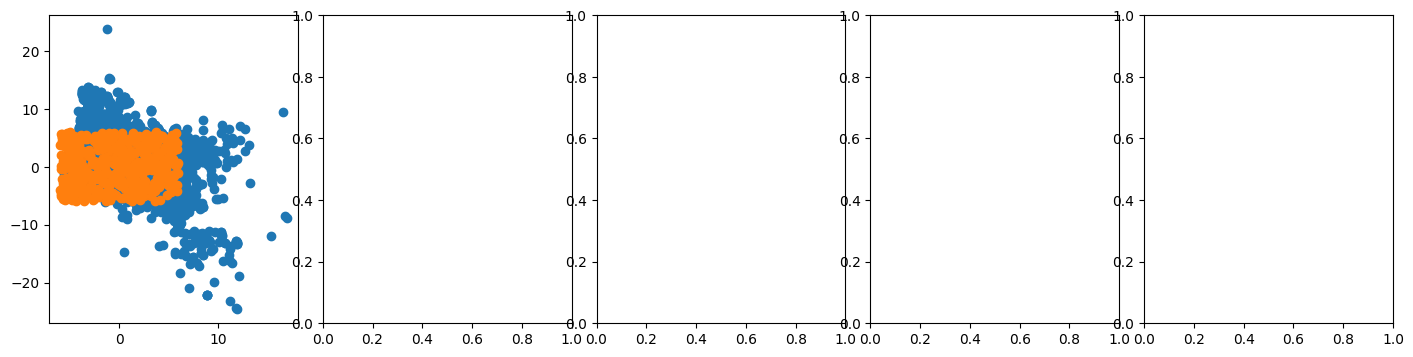

In [65]:
rng = np.random.RandomState(42)

_, subaxes = plt.subplots(1, 5, figsize=(14, 4))
# plt.subplots_adjust(left=.02, right=.98, bottom=.001, top=.96, wspace=.05,hspace=.01)
plt.subplots_adjust(left=.02, right=.98, wspace=.1)
for ax, X in zip(subaxes, datasets):
    outliers = rng.uniform(low=-6, high=6, size=(n_outliers, 2))
    ax.scatter(X[:, 0], X[:, 1])
    ax.scatter(outliers[:, 0], outliers[:, 1])

D:\Python\Python313\Lib\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(
D:\Python\Python313\Lib\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


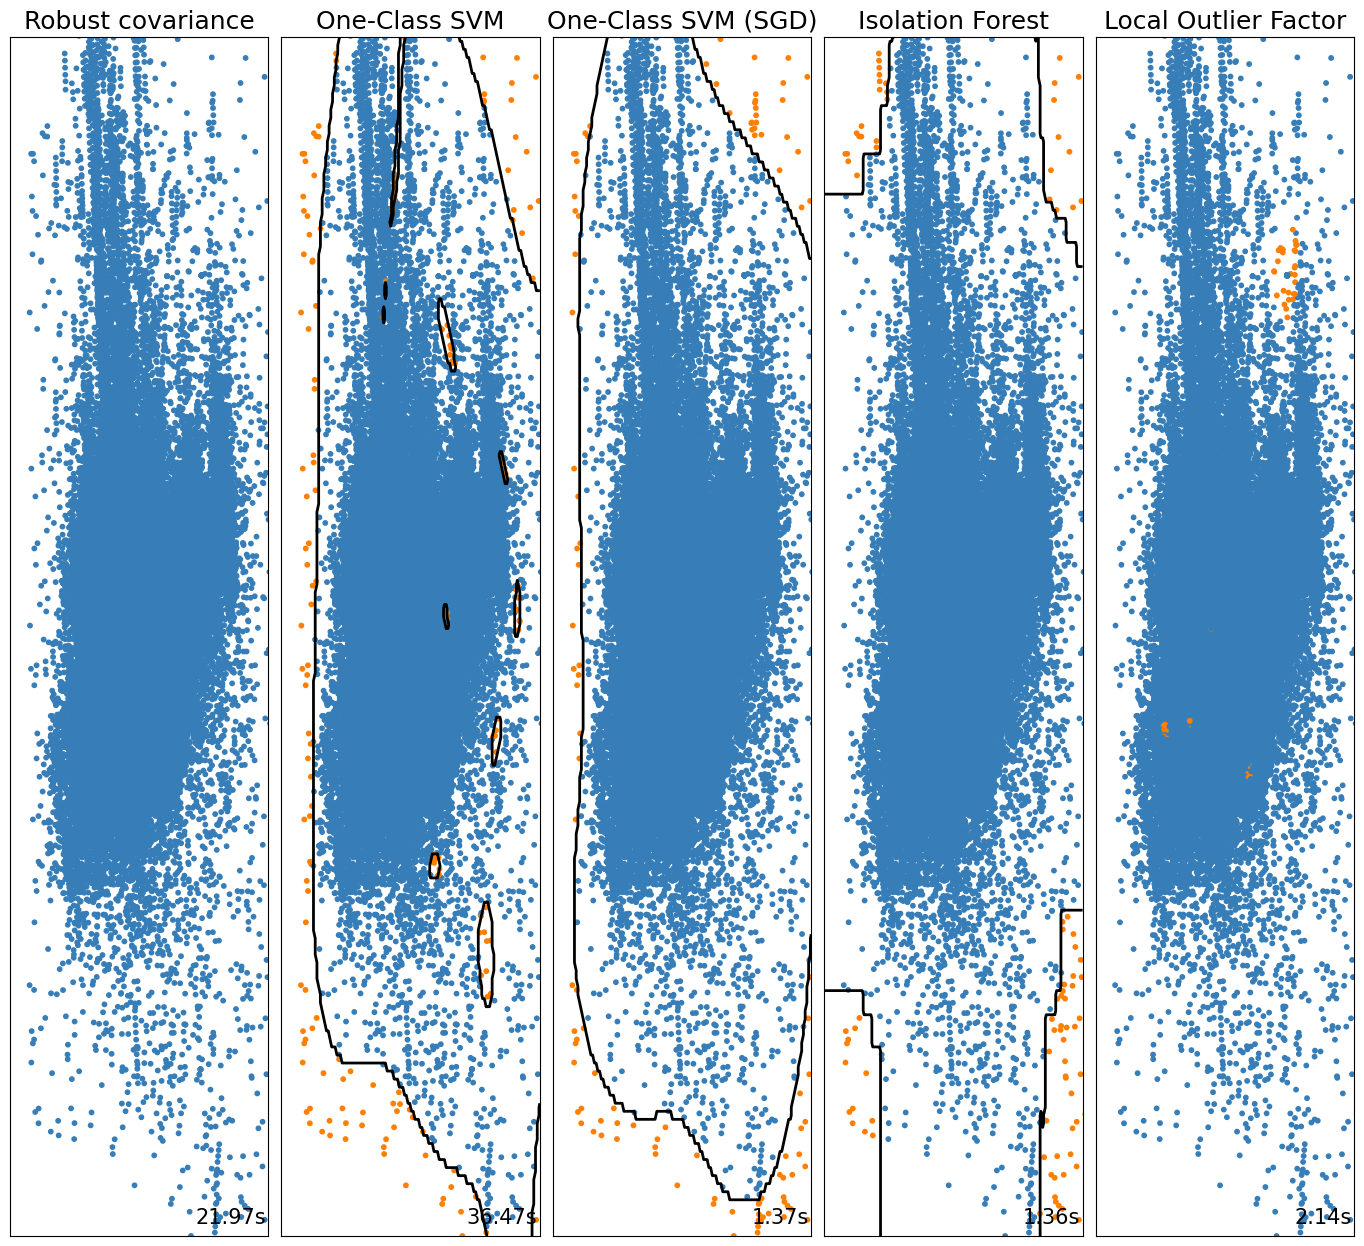

In [66]:
xx, yy = np.meshgrid(np.linspace(-7, 7, 150), np.linspace(-7, 7, 150))

plt.figure(figsize=(len(anomaly_algorithms) * 2 + 4, 12.5))
plt.subplots_adjust(
    left=0.02, right=0.98, bottom=0.001, top=0.96, wspace=0.05, hspace=0.01
)

plot_num = 1
rng = np.random.RandomState(42)

for i_dataset, X in enumerate(datasets):
    # Add outliers
    X = np.concatenate([X, rng.uniform(low=-6, high=6, size=(n_outliers, 2))], axis=0)

    for name, algorithm in anomaly_algorithms:
        t0 = time.time()
        algorithm.fit(X)
        t1 = time.time()
        plt.subplot(len(datasets), len(anomaly_algorithms), plot_num)
        if i_dataset == 0:
            plt.title(name, size=18)

        # fit the data and tag outliers
        if name == "Local Outlier Factor":
            y_pred = algorithm.fit_predict(X)
        else:
            y_pred = algorithm.fit(X).predict(X)

        # plot the levels lines and the points
        if name != "Local Outlier Factor":  # LOF does not implement predict
            Z = algorithm.predict(np.c_[xx.ravel(), yy.ravel()])
            Z = Z.reshape(xx.shape)
            plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors="black")

        colors = np.array(["#ff7f00", "#377eb8"])
        plt.scatter(X[:, 0], X[:, 1], s=10, color=colors[(y_pred + 1) // 2])

        plt.xlim(-7, 7)
        plt.ylim(-7, 7)
        plt.xticks(())
        plt.yticks(())
        plt.text(
            0.99,
            0.01,
            ("%.2fs" % (t1 - t0)).lstrip("0"),
            transform=plt.gca().transAxes,
            size=15,
            horizontalalignment="right",
        )
        plot_num += 1

plt.show()
